In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from scipy import stats
import seaborn as sns
from collections import Counter

%matplotlib inline

# Helper function

In [2]:
def paired_line(data, lines, column1, cond1_ls, x_axis):
    plt.rcParams["figure.figsize"] = (3,10)
    ax = sns.pointplot(x=cond1_ls, y=column1, data=data)
    sns.despine()
    

def non_unique(l):
    def low(x):
        return x.lower() if isinstance(x, str) else x
    c = Counter(map(low, l))
    return [x for x in l if c[low(x)] > 1]

In [3]:
sns.set_context("notebook", rc={"font.family": 'sans-serif',
                                'font.sans-serif': 'DejaVu Sans'})

# AgRP chemogenetics

In [4]:
data = pd.read_csv('chemogenetics.csv', encoding='cp1252')
data = data[data['receptor'].isin(['Gq', 'mCher'])]
data_pre = data.groupby(['receptor', 'state_D2']).size().reset_index(name='n')
data_post = data.groupby(['receptor', 'state_after']).size().reset_index(name='n')
#data_D2 = data.groupby(['receptor', 'state_D2']).size().reset_index(name='n')
data_pre.loc[-1] = ['Gq', 'Agg+', 0]
data_pre.loc[-2] = ['mCher', 'Agg+', 0]

data_pre = data_pre.rename(columns = {'state_D2': 'state'})
data_post = data_post.rename(columns = {'state_after': 'state'})

data_t = pd.concat([data_pre, data_post], keys = ['CNO-', 'CNO+'])
data_t.reset_index(inplace = True)
data_t.loc[-1] = ['CNO+', 2,'mCher', 'Agg+', 0]

data_count = data.groupby(['receptor']).size().reset_index(name = 'count')
data_per = data_t.merge(data_count, how = 'outer', on = 'receptor')
data_per['percentage'] = data_per['n'] / data_per['count'] *100

In [5]:
Gq_dat = data[data['receptor'] == 'Gq']
stat, p = stats.ttest_rel(Gq_dat['food_consumption_null'],
                           Gq_dat['food_consumption_CNO'])
print(p)

9.698631809291145e-05


In [6]:
print(data_per.n.dtype)

int64


In [7]:
d1 = data_per[(data_per['receptor'] == 'Gq') & (data_per['state'] == 'Agg+')].reset_index()
d2 = data_per[(data_per['receptor'] == 'Gq') & (data_per['state'] == 'Agg-')].reset_index()
print(d1)
d = np.array([[d1.n[0], d2.n[0]],
      [d1.n[1], d2.n[1]]])
print(d.dtype)

   index level_0  level_1 receptor state  n  count  percentage
0      1    CNO-       -1       Gq  Agg+  0      7    0.000000
1      2    CNO+        0       Gq  Agg+  6      7   85.714286
int64


In [8]:
_, p  =  stats.fisher_exact(d)
print(p)

0.004662004662004674


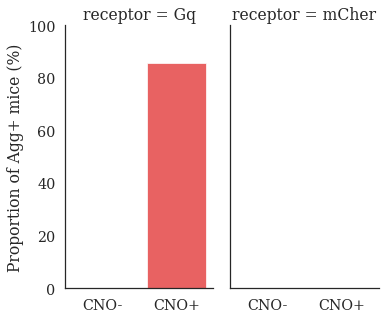

In [9]:
data_per = data_per[data_per['receptor'].isin(['Gq', 'mCher'])]

sns.set(rc={'figure.figsize':(8,5)}, font_scale = 1.3)
sns.set_style("white", {'font.family':'serif'})
g = sns.catplot(x = 'level_0',
                y = 'percentage',
                col = 'receptor',
                data = data_per[data_per['state'] == 'Agg+'],
                kind = 'bar',
                alpha = 0.7, 
                palette = ['red'],
                aspect = 2.2/4)

g.set(xlabel = None)
g.set(ylabel = 'Proportion of Agg+ mice (%)')
plt.ylim([0,100])
sns.despine()
plt.savefig('chemogenetics.jpg', dpi=300,bbox_inches='tight')

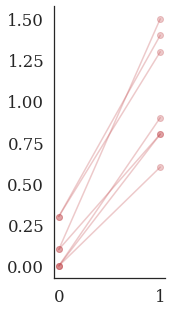

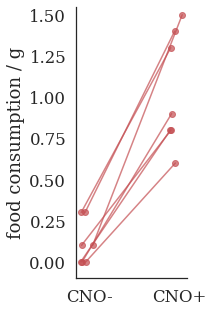

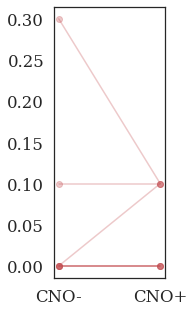

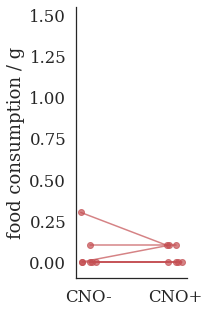

In [10]:
fig = plt.figure(figsize = (2,5))
sns.set(font_scale=1.5)
sns.set_style("white", {'font.family':'serif'})
x_axis = ['CNO-', 'CNO+']
jitter_x = []

# Gq food consumption with and without CNO
lines_Gq = data[data['receptor'] == 'Gq'][['food_consumption_null', 'food_consumption_CNO']].values.tolist()
    

for i in range(len(lines_Gq)):
    plt.plot(lines_Gq[i], 'ro-', alpha = 0.3)
    ax = plt.gca()
    lines = ax.lines
    jitter_x.append(lines[i].get_xdata() + np.random.uniform(-0.1, 0.1))
    
sns.despine()

fig = plt.figure(figsize = (2,5))
for i in range(len(lines_Gq)):
    plt.plot(jitter_x[i], lines_Gq[i], 'ro-', alpha = 0.7)
    ax = plt.gca()

    
sns.despine()
jitter_x2 = []
plt.ylabel('food consumption / g')
#plt.title('Gq food consumption')
ax.set_ylim([-0.1, 1.55])
ax.set_xticks(np.arange(2), ('CNO-', 'CNO+'))
plt.savefig('Gq_food.jpg', dpi=300,bbox_inches='tight')


# mCher food consumption with and without CNO
fig2 = plt.figure(figsize = (2,5))
lines_mcher = data[data['receptor'] == 'mCher'][['food_consumption_null', 'food_consumption_CNO']].values.tolist()


for i in range(len(lines_mcher)):
    plt.plot(x_axis, lines_mcher[i], 'ro-', alpha = 0.3)
    jitter_x2.append(lines[i].get_xdata() + np.random.uniform(-0.1, 0.1))


fig = plt.figure(figsize = (2,5))
for i in range(len(lines_mcher)):
    plt.plot(jitter_x2[i], lines_mcher[i], 'ro-', alpha = 0.7)

sns.despine()
ax = plt.gca()
ax.set_ylim([-0.1, 1.55])
ax.set_xticks(np.arange(2), ('CNO-', 'CNO+'))

plt.ylabel('food consumption / g')
#plt.title('mCher food consumption')
plt.savefig('mCher_food.jpg', dpi=300,bbox_inches='tight')